In [46]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#It ignores non critical(small) warning
print("All libraries imporrted successfully")
print("pandas version:",pd.__version__)
print("sqlite3 version:",sqlite3.version)

All libraries imporrted successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
df=pd.read_csv('student_performance.csv')
print(df.shape[0],"students")
print(df.shape[1],"columns")
print("\n First 3 rows:")
print(df.head(3))

30 students
13 columns

 First 3 rows:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2                     78      Delhi            2023  


In [49]:
conn=sqlite3.connect('college.db')#creating database named college.db in th colab filesystem if it is already present it opens that
cursor=conn.cursor()
df.to_sql('students',conn,if_exists='replace',index=False)#creating table named students in college.db and conn is used to give which database connection to use
cursor.execute('SELECT COUNT(*) FROM students')
count=cursor.fetchone()[0]#fetchdone returns first result row
print("Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")


Database 'college.db' created successfully!
Table 'students' has 30 rows


In [50]:
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("Table structure of 'students':")
print(f"{'Column Name':<25}{'Data Type':<12}")
print("-"*40)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<122}")

Table structure of 'students':
Column Name              Data Type   
----------------------------------------
student_id               INTEGER                                                                                                                   
name                     TEXT                                                                                                                      
age                      INTEGER                                                                                                                   
gender                   TEXT                                                                                                                      
department               TEXT                                                                                                                      
semester                 INTEGER                                                                                                                   
ma

In [51]:
def run_query(sql,description=""):
  if description:
    print(f"\n{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result



1. find total number of students
2. display all column names and data types using pragma
3. show first 5 rows from the students table
4. display students with math mark >

In [52]:
#show first 5 rows from the students table
cursor.execute("SELECT * FROM students LIMIT 5")
rows=cursor.fetchall()
print("\nFirst 5 rows from the 'students' table:")
for row in rows:
  print(row)


First 5 rows from the 'students' table:
(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
(1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
(1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)
(1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023)
(1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023)


In [53]:
#display students with math mark >80
cursor.execute("SELECT name FROM students WHERE math_score>80")
rows=cursor.fetchall()
print("\nStudents with math mark >80:")
for row in rows:
  print(row)


Students with math mark >80:
('Aarav Sharma',)
('Arjun Nair',)
('Divya Singh',)
('Ananya Das',)
('Suresh Rao',)
('Ritu Agarwal',)
('Swati Kulkarni',)
('Tanvi Mehta',)
('Amit Bose',)
('Gaurav Shukla',)
('Akanksha Yadav',)


In [54]:
query1="SELECT name, gender from students"
run_query(query1,"name and gender of students")


name and gender of students
          name gender
  Aarav Sharma   Male
   Priya Patel Female
   Rohit Verma   Male
   Sneha Reddy Female
    Arjun Nair   Male
   Meera Joshi Female
   Kiran Kumar   Male
   Divya Singh Female
  Rahul Mishra   Male
    Ananya Das Female
   Vikram Iyer   Male
   Pooja Gupta Female
    Suresh Rao   Male
 Kavya Nambiar Female
   Ajay Tiwari   Male
  Ritu Agarwal Female
  Manoj Pandey   Male
Swati Kulkarni Female
Deepak Chauhan   Male
  Nisha Kapoor Female
 Harish Pillai   Male
   Tanvi Mehta Female
  Sanjay Dubey   Male
 Preeti Saxena Female
     Amit Bose   Male
    Rekha Nair Female
 Gaurav Shukla   Male
 Sunita Pillai Female
    Nitin Jain   Male
Akanksha Yadav Female


,name,gender
0,Aarav Sharma,Male
1,Priya Patel,Female
2,Rohit Verma,Male
3,Sneha Reddy,Female
4,Arjun Nair,Male
5,Meera Joshi,Female
6,Kiran Kumar,Male
7,Divya Singh,Female
8,Rahul Mishra,Male
9,Ananya Das,Female


In [55]:
query2="SELECT name , math_score from students ORDER BY math_score desc LIMIT 5"
run_query(query2," display name and math score of top 5 students based on math score")


 display name and math score of top 5 students based on math score
          name  math_score
    Ananya Das          95
   Tanvi Mehta          93
    Arjun Nair          92
Akanksha Yadav          91
Swati Kulkarni          90


,name,math_score
0,Ananya Das,95
1,Tanvi Mehta,93
2,Arjun Nair,92
3,Akanksha Yadav,91
4,Swati Kulkarni,90


In [56]:
query3="SELECT name,math_score,science_score,programming_score,attendance_percentage from students where department='Computer Science' order by programming_score desc LIMIT 5"
run_query(query3,"top 5 students from cumputer science department based on progrmming score")
#


top 5 students from cumputer science department based on progrmming score
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96


,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96


In [57]:
query4="select name,department,attendance_percentage from students where attendance_percentage>90 and department!='Civil'order by attendance_percentage desc"
run_query(query4,"students with attendance_percentage>90 and not from civil department")


students with attendance_percentage>90 and not from civil department
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Divya Singh,Computer Science,96
3,Sneha Reddy,Mechanical,95
4,Akanksha Yadav,Computer Science,95
5,Swati Kulkarni,Computer Science,94
6,Ritu Agarwal,Electronics,93
7,Aarav Sharma,Computer Science,92
8,Kavya Nambiar,Mechanical,91
9,Amit Bose,Computer Science,91


In [58]:
query5="select department, count(*) as no_of_students,round(avg(math_score),2)as avg_math,round(avg(science_score),2)as avg_science,round(avg(programming_score))as avg_peogramming,round(avg(attendance_percentage))as avg_attendance from students group by department "
run_query(query5,"department wise average")


department wise average
      department  no_of_students  avg_math  avg_science  avg_peogramming  avg_attendance
           Civil               5     63.40        66.60             41.0            75.0
Computer Science              13     85.62        84.46             89.0            91.0
     Electronics               6     71.00        74.17             62.0            80.0
      Mechanical               6     71.00        76.50             49.0            84.0


,department,no_of_students,avg_math,avg_science,avg_peogramming,avg_attendance
0,Civil,5,63.40,66.60,41.0,75.0
1,Computer Science,13,85.62,84.46,89.0,91.0
2,Electronics,6,71.00,74.17,62.0,80.0
3,Mechanical,6,71.00,76.50,49.0,84.0


In [59]:
query6="select department,round(avg(math_score),2)as avg_math,COUNT(*) as number_of_students from students group by department having avg_math>70 order by avg_math desc"
run_query(query6,"department wise average math score greater than 70")


department wise average math score greater than 70
      department  avg_math  number_of_students
Computer Science     85.62                  13
      Mechanical     71.00                   6
     Electronics     71.00                   6


,department,avg_math,number_of_students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


In [60]:
query7="select gender,count(*) as num_students,round(avg(math_score),2) as avg_math,round(avg(programming_score),2)as avg_pro_score from students group by gender"
run_query(query7,"gender wise average math and programming score")


gender wise average math and programming score
gender  num_students  avg_math  avg_pro_score
Female            15     78.47           70.2
  Male            15     73.67           65.0


,gender,num_students,avg_math,avg_pro_score
0,Female,15,78.47,70.2
1,Male,15,73.67,65.0


In [61]:
query8="select name, department, math_score+science_score+programming_score as total_score from students order by total_score desc limit 5"
run_query(query8,"top 5 students based on total score")


top 5 students based on total score
          name       department  total_score
    Ananya Das Computer Science          281
   Tanvi Mehta Computer Science          279
Akanksha Yadav Computer Science          278
    Arjun Nair Computer Science          275
   Divya Singh Computer Science          272


,name,department,total_score
0,Ananya Das,Computer Science,281
1,Tanvi Mehta,Computer Science,279
2,Akanksha Yadav,Computer Science,278
3,Arjun Nair,Computer Science,275
4,Divya Singh,Computer Science,272


In [62]:
dept_data={
    'dept_code': ['cs','ec','me','ce'],
    'dept_name': ['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name': ['Dr. suba','Dr. rama','Dr. ravi','Dr. kumar'],
    'establishied_year': [2000,2001,2002,2003],
    'intake' : [60,50,80,90]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("created department table")
print(dept_df.to_string(index=False))

created department table
dept_code        dept_name  hod_name  establishied_year  intake
       cs Computer Science  Dr. suba               2000      60
       ec      Electronics  Dr. rama               2001      50
       me       Mechanical  Dr. ravi               2002      80
       ce            Civil Dr. kumar               2003      90


In [63]:
query_join="select s.name,s.math_score,d.dept_name,d.hod_name,d.establishied_year from students as s inner join departments as d on s.department=d.dept_name order by s.math_score desc limit 8"
run_query(query_join,"students with their department details")



students with their department details
          name  math_score        dept_name hod_name  establishied_year
    Ananya Das          95 Computer Science Dr. suba               2000
   Tanvi Mehta          93 Computer Science Dr. suba               2000
    Arjun Nair          92 Computer Science Dr. suba               2000
Akanksha Yadav          91 Computer Science Dr. suba               2000
Swati Kulkarni          90 Computer Science Dr. suba               2000
   Divya Singh          88 Computer Science Dr. suba               2000
  Ritu Agarwal          87      Electronics Dr. rama               2001
     Amit Bose          86 Computer Science Dr. suba               2000


,name,math_score,dept_name,hod_name,establishied_year
0,Ananya Das,95,Computer Science,Dr. suba,2000
1,Tanvi Mehta,93,Computer Science,Dr. suba,2000
2,Arjun Nair,92,Computer Science,Dr. suba,2000
3,Akanksha Yadav,91,Computer Science,Dr. suba,2000
4,Swati Kulkarni,90,Computer Science,Dr. suba,2000
5,Divya Singh,88,Computer Science,Dr. suba,2000
6,Ritu Agarwal,87,Electronics,Dr. rama,2001
7,Amit Bose,86,Computer Science,Dr. suba,2000


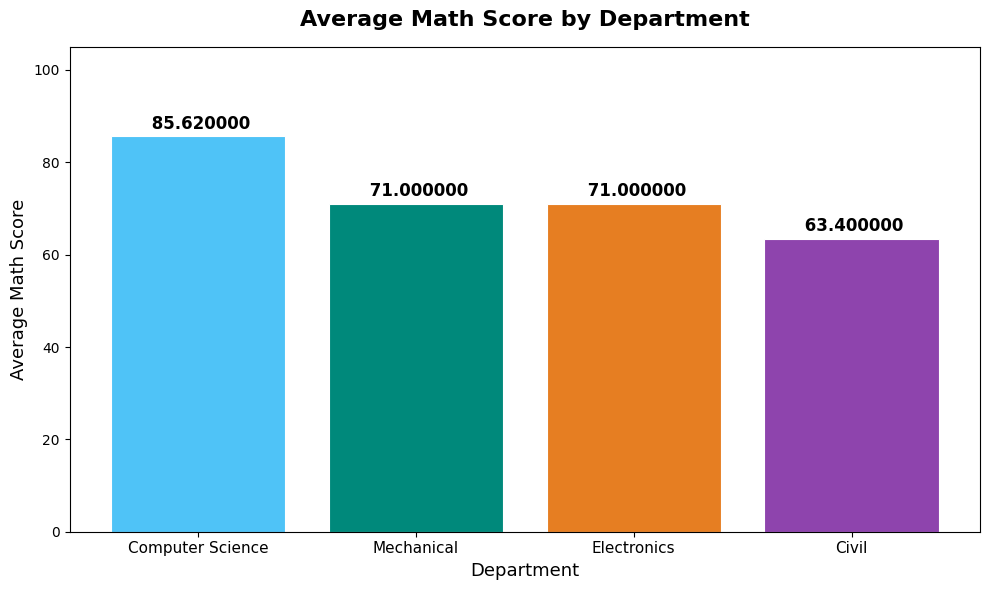

In [64]:
# Step 1: Get data using SQL
chart1_sql = "SELECT department, ROUND(AVG(math_score),2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC"
chart1_data = pd.read_sql_query(chart1_sql, conn)
# Step 2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
# fig = the whole figure (canvas)
# ax = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
# List of hex color codes - one color per department bar
# Same color palette as our PPT slides for consistency

bars = ax.bar(
chart1_data['department'],
chart1_data['avg_math'],
color=bar_colors,
edgecolor='white',
linewidth=0.8
)
# x-axis values (category labels)
# y-axis values (heights of bars)
# colors for each bar
# white border around each bar
# thickness of the border
# Add value labels ON TOP of each bar
for bar in bars:
   height = bar.get_height()
# .get_height() returns the bar's height (= the avg_math value)
   ax.text(
      bar.get_x() + bar.get_width() / 2, # x position: center of bar
      height + 0.8,
      f'{height : 1f}',
      ha='center', va='bottom',
      fontsize=12, fontweight='bold',
)
# y position: just above bar top
# text: height formatted to 1 decimal
# horizontal/vertical alignment
ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105) # y-axis from 0 to 105 so labels above bars fit
ax.tick_params(axis='x', labelsize=11)
# axis='y' adds horizontal gridlines only
# alpha=0.3 makes gridlines 70% transparent
# linestyle=' -- ' makes them dashed

plt.tight_layout()
plt.show()


# Adjusts spacing to prevent label clipping
# Displays the chart

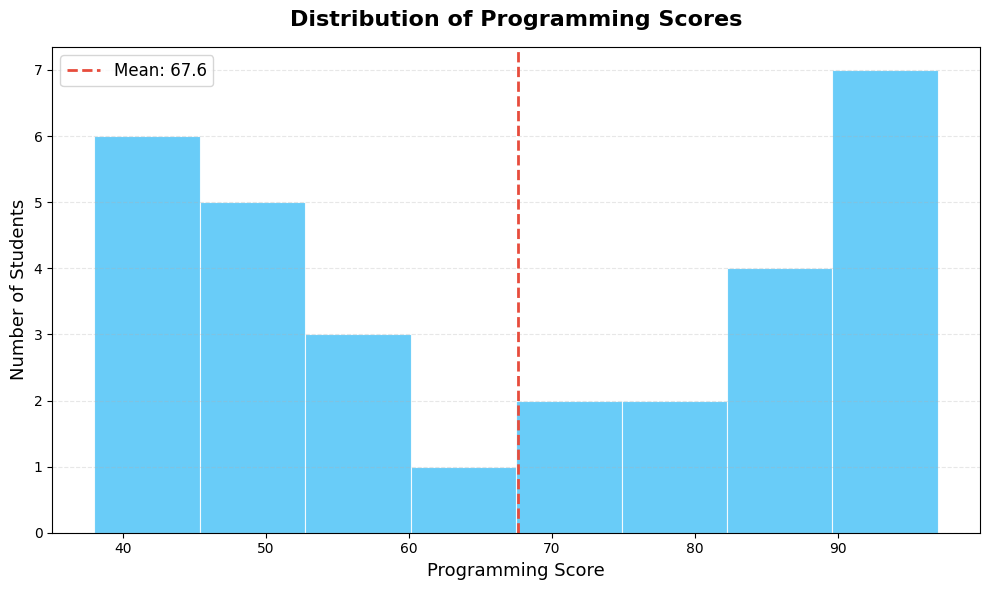

In [65]:
# Get programming scores as a list
prog_scores = df['programming_score'].tolist()
# .tolist() converts a Pandas Series to a regular Python list
# Matplotlib's hist() works with both - tolist() is just explicit

fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
# The data to visualize
# Divide score range into 8 equal intervals
# Bar fill color
# White border between bars

# Slight transparency
# Add a vertical line showing the mean score
mean_score = sum(prog_scores) / len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}' # label for the legend
)
# axvline = 'axis vertical line' - draws a vertical reference line

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.legend(fontsize=12) # Shows the mean line label
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# x position of the vertical line
# red color for visibility
# dashed line style

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
'Category': np.random. choice(['A','B','c','D'], 100),
'Value': np.random.randint(10, 100, 100),
'Score': np.random.randint(1, 10, 100)
})

df.head()

,Category,Value,Score
0,D,56,7
1,B,27,4
2,B,35,8
3,D,64,7
4,A,41,7


In [70]:
import plotly.express as px

category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

fig = px.bar(
      category_counts,
      x='Category',
      y='Count',
      color='Category',
      title='Interactive Category Distribution',
      text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Category', yaxis_title='Count')
fig.show()

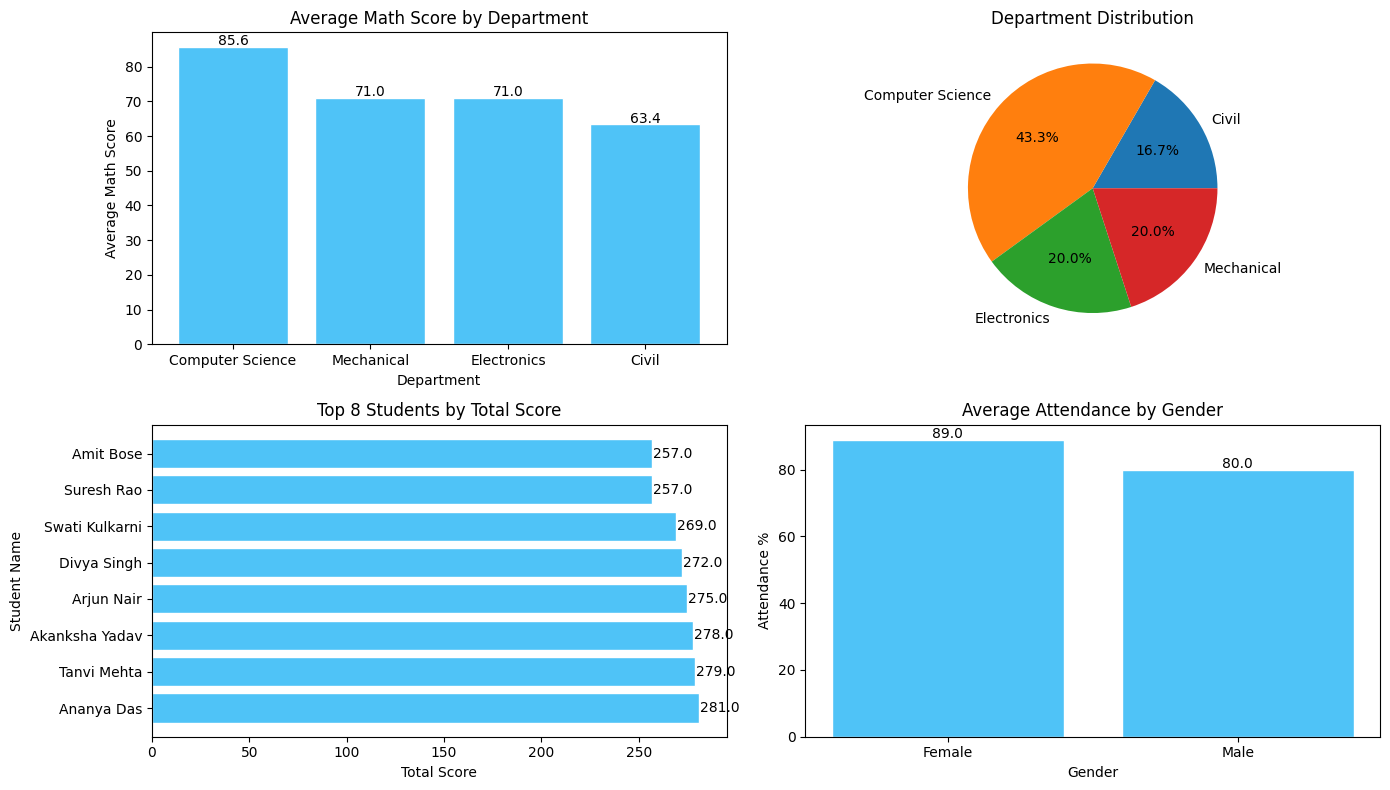

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# ---------------- Chart 1 ----------------
ch1 = """
SELECT department,
ROUND(AVG(math_score),2) as avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
ch1_data = pd.read_sql_query(ch1, conn)

bars = axs[0,0].bar(
    ch1_data['department'],
    ch1_data['avg_math'],
    color='#4FC3F7',
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    axs[0,0].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center'
    )

axs[0,0].set_title('Average Math Score by Department')
axs[0,0].set_xlabel('Department')
axs[0,0].set_ylabel('Average Math Score')

# ---------------- Chart 2 ----------------
ch2 = """
SELECT department,
COUNT(*) as num_students
FROM students
GROUP BY department
"""
ch2_data = pd.read_sql_query(ch2, conn)

axs[0,1].pie(
    ch2_data['num_students'],
    labels=ch2_data['department'],
    autopct='%1.1f%%'
)

axs[0,1].set_title('Department Distribution')

# ---------------- Chart 3 ----------------
ch3 = """
SELECT name,
math_score + science_score + programming_score as total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
ch3_data = pd.read_sql_query(ch3, conn)

bars=axs[1,0].barh(
    ch3_data['name'],
    ch3_data['total_score'],
    color='#4FC3F7',
    edgecolor='white'
)
for bar in bars:
    width = bar.get_width()
    axs[1,0].text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

axs[1,0].set_title('Top 8 Students by Total Score')
axs[1,0].set_xlabel('Total Score')
axs[1,0].set_ylabel('Student Name')

# ---------------- Chart 4 ----------------
ch4 = """
SELECT gender,
ROUND(AVG(attendance_percentage)) as avg_attendance
FROM students
GROUP BY gender
"""
ch4_data = pd.read_sql_query(ch4, conn)

bars = axs[1,1].bar(
    ch4_data['gender'],
    ch4_data['avg_attendance'],
    color='#4FC3F7',
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    axs[1,1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center'
    )

axs[1,1].set_title('Average Attendance by Gender')
axs[1,1].set_xlabel('Gender')
axs[1,1].set_ylabel('Attendance %')

# Adjust layout
plt.tight_layout()

# Show all charts
plt.show()